In [1]:
import pandas as pd
import seaborn as sns
from lifelines import AalenJohansenFitter
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import fisher_exact

In [2]:
df = pd.read_csv('cricket_detailed_behaviour.csv')

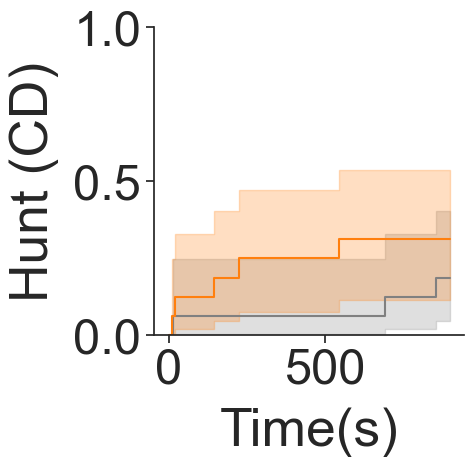

In [3]:
# change palette to orange and gray
sns.set(rc={"figure.figsize": (4, 4)})
sns.set(font_scale=3.2) 
sns.set_style("ticks")
sns.set_palette(['gray', 'Tab:orange'])

df['cricket_binary'] = df.cricket_state.apply(lambda x: 1 if x == 'Hunt+' else 0)
df.loc[df.cricket_state == 'Hunt-', 'cricket_latency'] = 15*60

ajf = AalenJohansenFitter(calculate_variance=True)
ajf.fit(df[df.state == 'Pre'].cricket_latency,df[df.state == 'Pre'].cricket_binary , event_of_interest=1)
ajf.cumulative_density_
ajf.plot()

ajf_ctrl = AalenJohansenFitter(calculate_variance=True)
ajf_ctrl.fit(df[df.state == 'Post'].cricket_latency,df[df.state == 'Post'].cricket_binary , event_of_interest=1)
ajf_ctrl.cumulative_density_
ajf_ctrl.plot()

# get the legend handle of the plot
handles, labels = plt.gca().get_legend_handles_labels()
# create a new legend from the last two handles
# plt.legend(handles[::], ['Npy \nKnockdown', 'Ctrl'], bbox_to_anchor=(0.3, 1.4), loc='upper left', borderaxespad=0.)
# remove legend
plt.legend([],[], frameon=False)
# remove top and right spines
sns.despine()
plt.ylim([0,1])
plt.xlabel('Time(s)', labelpad=10)
plt.ylabel('Hunt (CD)', labelpad=10)
plt.savefig('output_figures/cricket_hunt.png', bbox_inches='tight', dpi = 300, transparent=True)

In [4]:
from lifelines.statistics import logrank_test
results = logrank_test(df[df.state == 'Pre'].cricket_latency, df[df.state == 'Post'].cricket_latency, event_observed_A=df[df.state == 'Pre'].cricket_binary, event_observed_B=df[df.state == 'Post'].cricket_binary)
results.print_summary()
print(f"P-value: {results.p_value:.10f}")

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.80 0.37      1.43

P-value: 0.3706283026


In [5]:
count = df.groupby(['state','cricket_consumption']).size().reset_index(name='counts')
ns =df.groupby(['state', 'cricket_state']).size().reset_index(name='ns')

In [6]:
grouped_df = pd.merge(count, ns, on=['state'])
grouped_df['percentage'] = grouped_df['counts']/grouped_df['ns']*100

/var/folders/nv/66_qlsw15fl17x359fwl6034qcrs_y/T/ipykernel_65516/3605203605.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state', y='percentage',


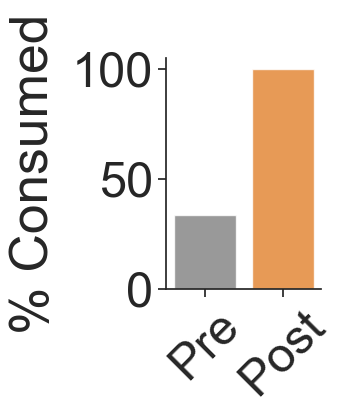

In [7]:
plt.subplots(figsize=(2, 3))
sns.barplot(x='state', y='percentage', 
            data=grouped_df[(grouped_df.cricket_consumption == 'yes') & (grouped_df.cricket_state == 'Hunt+')], 
            order=['Pre', 'Post'],
            palette=['gray', 'Tab:orange'], alpha = 0.8)
plt.xticks(rotation=45)
plt.xlabel('')
plt.ylabel('% Consumed', labelpad=10)
plt.title(' ')
plt.yticks([0, 50, 100])
sns.despine()
plt.savefig('output_figures/cricket_consumption.pdf', bbox_inches='tight', dpi = 300, transparent=True)

In [10]:
fisher_exact(grouped_df[grouped_df.cricket_state == 'Hunt+'].pivot(index='state', columns='cricket_consumption', values='counts').fillna(0))

SignificanceResult(statistic=0.0, pvalue=0.10714285714285714)